# Random forest classifier

In [ ]:
import pandas as pd

df = pd.read_csv("data/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [6]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

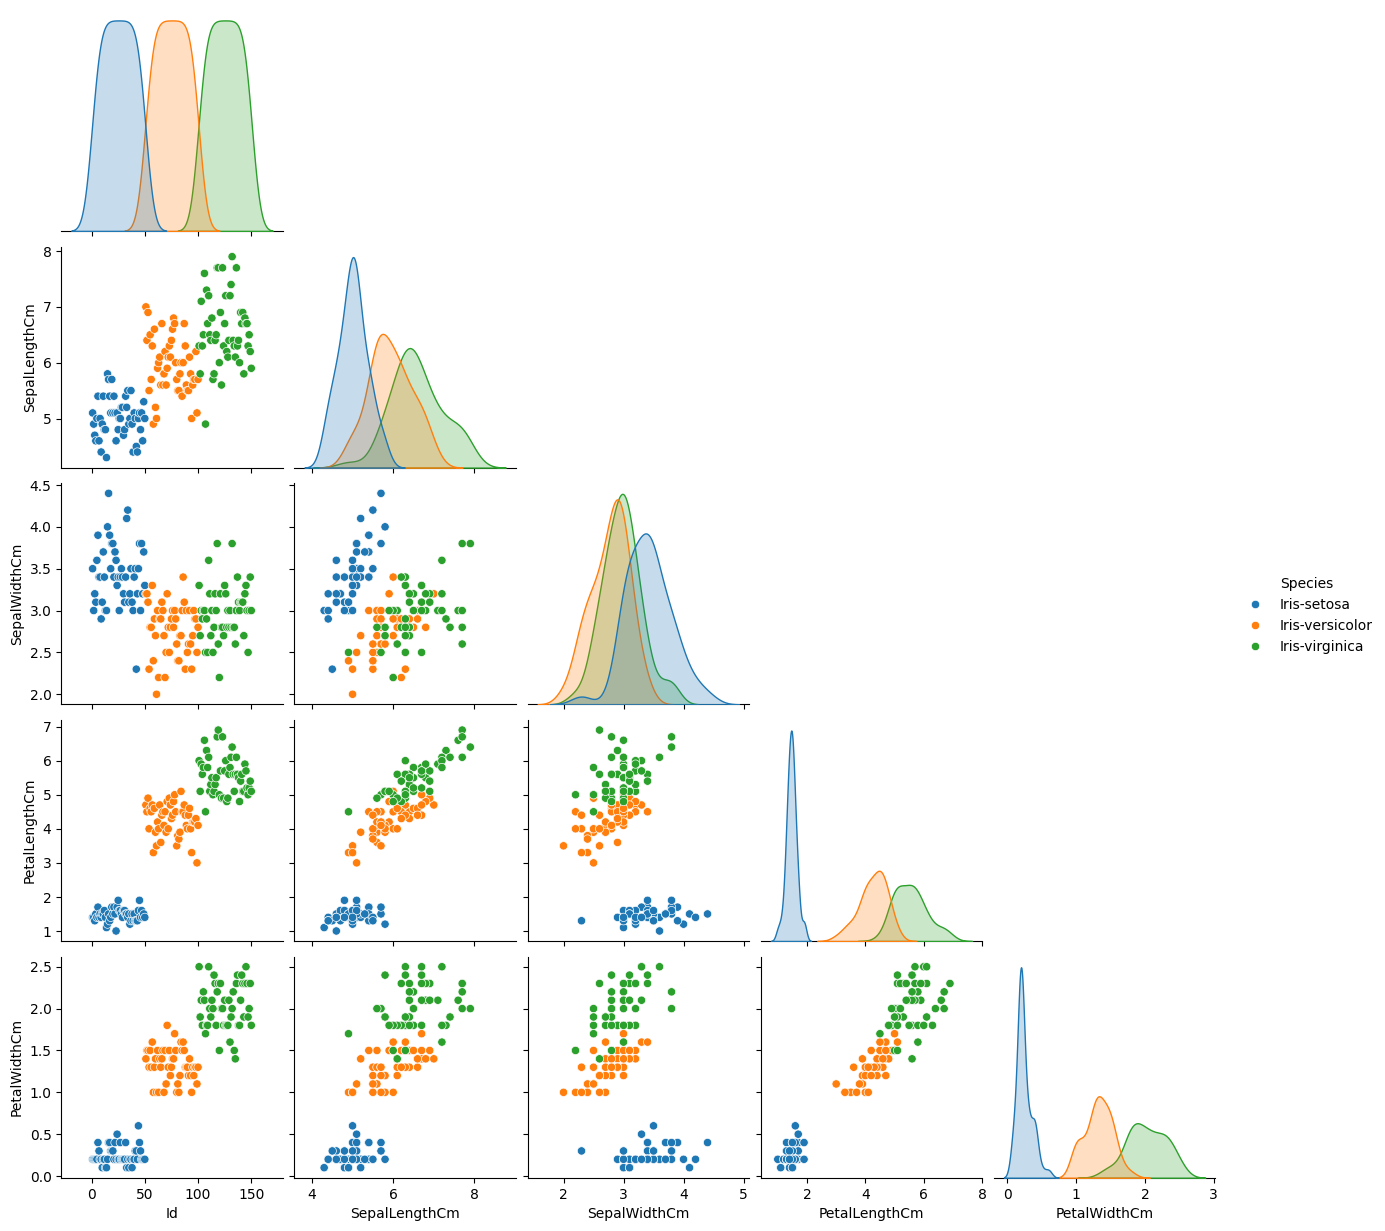

In [8]:
import seaborn as sns
sns.pairplot(df, corner=True, hue="Species")

## Random forest classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = df.drop(["Species"], axis = 1), df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.5, random_state=42)

clf = RandomForestClassifier()

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred[:10]


array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype=object)

In [18]:
y_test[:10].values

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype=object)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        29
Iris-versicolor       1.00      1.00      1.00        23
 Iris-virginica       1.00      1.00      1.00        23

       accuracy                           1.00        75
      macro avg       1.00      1.00      1.00        75
   weighted avg       1.00      1.00      1.00        75



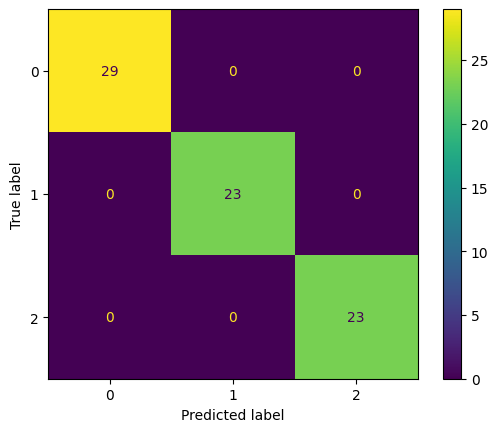

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

## Train on all data

- satisfied with the model
- train with all data
- export model

In [ ]:
import joblib
clf.fit(X,y)
joblib.dump(clf, "models/iris_classifier.joblib", compress=("xz", 3), protocol=5)



['models/iris_classifier.joblib']

In [24]:
clf = joblib.load("models/iris_classifier.joblib")

X_test.iloc[0]

Id               74.0
SepalLengthCm     6.1
SepalWidthCm      2.8
PetalLengthCm     4.7
PetalWidthCm      1.2
Name: 73, dtype: float64

In [25]:
sample_test_data = pd.DataFrame(X_test.iloc[0]).T
sample_test_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
73,74.0,6.1,2.8,4.7,1.2


In [26]:
clf.predict(sample_test_data)

array(['Iris-versicolor'], dtype=object)